In [5]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Please enable GPU in Colab.")

PyTorch version: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


In [6]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [7]:
import zipfile
import os

zip_path = "/content/archive (1).zip"
extract_path = "/content/traffic_color_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [8]:
import os

for root, dirs, files in os.walk("/content/traffic_color_dataset"):
    level = root.replace("/content/traffic_color_dataset", "").count(os.sep)
    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

traffic_color_dataset/
  ALI_NOOR_Small_Traffic_Lights_Color_Dataset/
    train/
    val/


In [9]:
import os

base_path = "/content/traffic_color_dataset/ALI_NOOR_Small_Traffic_Lights_Color_Dataset"

for split in ["train", "val"]:
    split_path = os.path.join(base_path, split)

    print("\n", split.upper())

    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            images = [
                f for f in os.listdir(class_path)
                if f.lower().endswith((".png", ".jpg", ".jpeg"))
            ]

            print(class_name, ":", len(images), "images")


 TRAIN
green : 1000 images
red : 910 images
yellow : 604 images

 VAL
green : 215 images
red : 186 images
yellow : 119 images


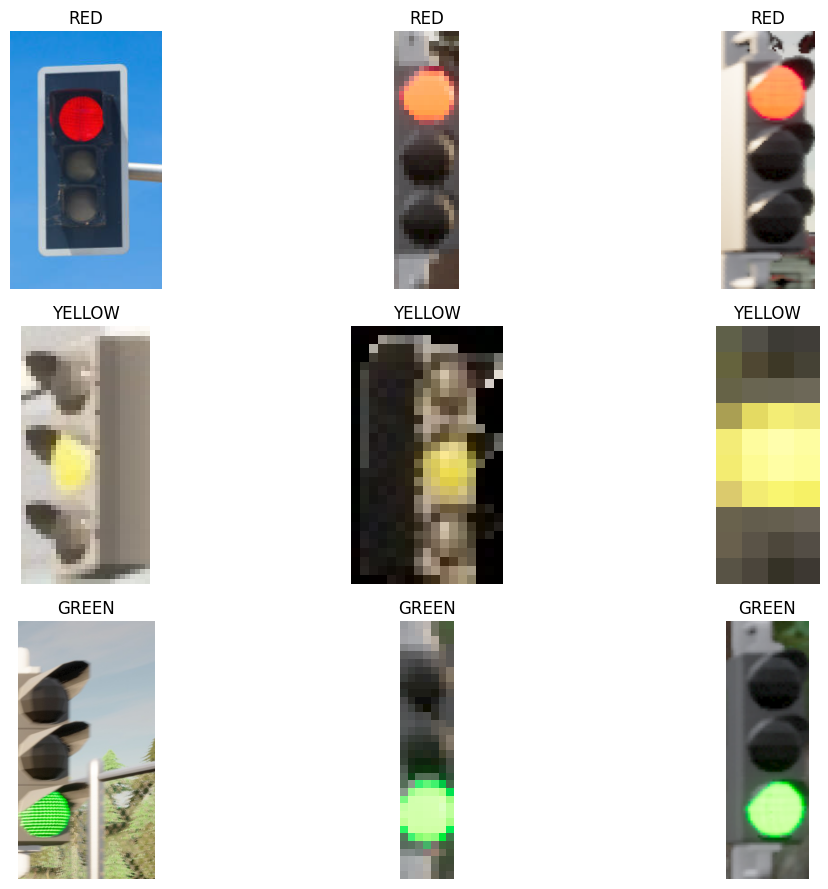

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

base_path = "/content/traffic_color_dataset/ALI_NOOR_Small_Traffic_Lights_Color_Dataset/train"

classes = ["red", "yellow", "green"]

plt.figure(figsize=(12, 9))

for i, class_name in enumerate(classes):

    class_path = os.path.join(base_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    samples = random.sample(images, 3)

    for j, image_name in enumerate(samples):

        image_path = os.path.join(class_path, image_name)
        image = Image.open(image_path)

        position = i * 3 + j + 1

        plt.subplot(3, 3, position)
        plt.imshow(image)
        plt.axis("off")
        plt.title(class_name.upper())

plt.tight_layout()
plt.show()

In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_path = "/content/traffic_color_dataset/ALI_NOOR_Small_Traffic_Lights_Color_Dataset/train"
val_path = "/content/traffic_color_dataset/ALI_NOOR_Small_Traffic_Lights_Color_Dataset/val"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    train_path,
    transform=transform
)

val_dataset = datasets.ImageFolder(
    val_path,
    transform=transform
)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Classes: ['green', 'red', 'yellow']
Training images: 2514
Validation images: 520


In [12]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 79
Validation batches: 17


In [13]:
import torch
import torch.nn as nn
from torchvision import models

# Load pretrained ResNet18
model = models.resnet18(weights="DEFAULT")

# Replace the final layer for 3 traffic-light classes
model.fc = nn.Linear(model.fc.in_features, 3)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Device:", device)
print("Model: ResNet18")
print("Number of classes:", 3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 217MB/s]


Device: cuda
Model: ResNet18
Number of classes: 3


In [14]:
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.0001")

Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.0001


In [15]:
num_epochs = 10

for epoch in range(num_epochs):

    # Training
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss/len(train_loader):.4f} "
        f"Train Accuracy: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss/len(val_loader):.4f} "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )

Epoch [1/10] Train Loss: 0.1061 Train Accuracy: 96.62% Val Loss: 0.0646 Val Accuracy: 97.88%
Epoch [2/10] Train Loss: 0.0108 Train Accuracy: 99.68% Val Loss: 0.0471 Val Accuracy: 98.27%
Epoch [3/10] Train Loss: 0.0017 Train Accuracy: 100.00% Val Loss: 0.0196 Val Accuracy: 99.62%
Epoch [4/10] Train Loss: 0.0010 Train Accuracy: 100.00% Val Loss: 0.0569 Val Accuracy: 97.69%
Epoch [5/10] Train Loss: 0.0009 Train Accuracy: 100.00% Val Loss: 0.0341 Val Accuracy: 98.65%
Epoch [6/10] Train Loss: 0.0005 Train Accuracy: 100.00% Val Loss: 0.0400 Val Accuracy: 98.46%
Epoch [7/10] Train Loss: 0.0004 Train Accuracy: 100.00% Val Loss: 0.0335 Val Accuracy: 98.85%
Epoch [8/10] Train Loss: 0.0013 Train Accuracy: 99.96% Val Loss: 0.0546 Val Accuracy: 98.08%
Epoch [9/10] Train Loss: 0.0114 Train Accuracy: 99.76% Val Loss: 0.1045 Val Accuracy: 97.31%
Epoch [10/10] Train Loss: 0.0129 Train Accuracy: 99.60% Val Loss: 0.0501 Val Accuracy: 98.65%


In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Classification report
print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

print("Confusion Matrix:")
print(cm)

              precision    recall  f1-score   support

       green       1.00      1.00      1.00       215
         red       0.96      1.00      0.98       186
      yellow       1.00      0.95      0.97       119

    accuracy                           0.99       520
   macro avg       0.99      0.98      0.98       520
weighted avg       0.99      0.99      0.99       520

Confusion Matrix:
[[214   1   0]
 [  0 186   0]
 [  0   6 113]]


In [17]:
import os
import torch

save_dir = "/content/traffic_color_classifier"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "best_color_classifier.pth")

torch.save(model.state_dict(), model_path)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: /content/traffic_color_classifier/best_color_classifier.pth


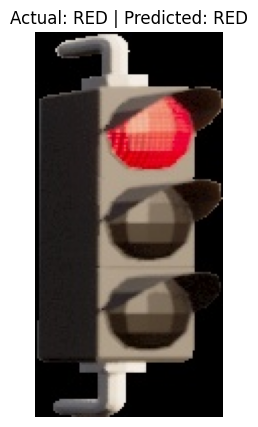

Actual: red
Predicted: red
Confidence: 99.65%


In [18]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Select a random image from validation dataset
image_path, true_label = random.choice(val_dataset.samples)

# Load image
image = Image.open(image_path).convert("RGB")

# Apply the same transformation used during training
input_tensor = transform(image).unsqueeze(0).to(device)

# Prediction
model.eval()

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()

predicted_label = train_dataset.classes[predicted_class]
true_label_name = train_dataset.classes[true_label]

# Display result
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Actual: {true_label_name.upper()} | "
    f"Predicted: {predicted_label.upper()}"
)
plt.show()

print("Actual:", true_label_name)
print("Predicted:", predicted_label)
print("Confidence:", f"{probabilities[0][predicted_class].item() * 100:.2f}%")

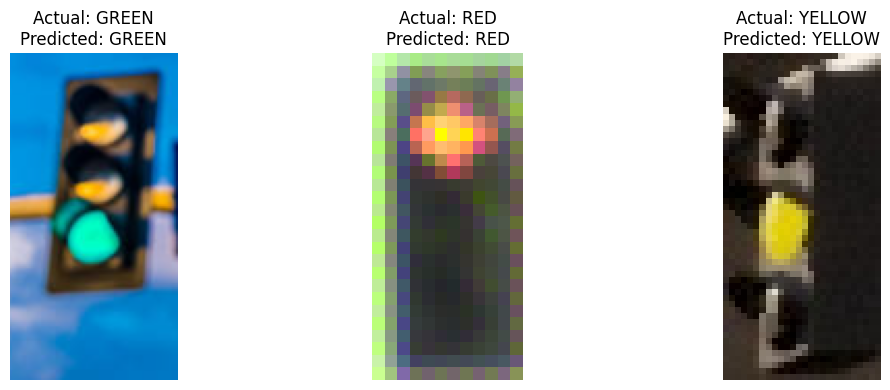

In [19]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import torch
import os

classes = train_dataset.classes

plt.figure(figsize=(12, 4))

for i, class_name in enumerate(classes):

    class_path = os.path.join(
        val_path,
        class_name
    )

    image_name = random.choice([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path).convert("RGB")

    input_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)

        predicted_class = torch.argmax(
            probabilities, dim=1
        ).item()

    predicted_label = classes[predicted_class]

    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Actual: {class_name.upper()}\n"
        f"Predicted: {predicted_label.upper()}"
    )

plt.tight_layout()
plt.show()

In [20]:
import os

detector_path = "/content/traffic_light_training/traffic_light_detector/weights/best.pt"

if os.path.exists(detector_path):
    print("YOLO detector found!")
    print(detector_path)
else:
    print("YOLO detector not found in this Colab.")

YOLO detector not found in this Colab.


In [21]:
!pip install -q ultralytics
from ultralytics import YOLO

# Load pretrained YOLO11n model
yolo_model = YOLO("yolo11n.pt")

print("YOLO11n model loaded successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 10.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO11n model loaded successfully!


In [22]:
yolo_model.info()

YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.7 GFLOPs


(181, 2624080, 0, 6.6733184)

In [23]:
import os

print("Checking /content for YOLO dataset folders...\n")

for item in os.listdir("/content"):
    if os.path.isdir(os.path.join("/content", item)):
        print("Folder:", item)
    elif item.endswith((".zip", ".yaml", ".yml")):
        print("File:", item)

Checking /content for YOLO dataset folders...

Folder: .config
Folder: traffic_color_classifier
Folder: traffic_color_dataset
File: archive (1).zip
Folder: sample_data


In [24]:
import os

print(os.listdir("/content"))

['.config', 'traffic_color_classifier', 'traffic_color_dataset', 'yolo11n.pt', 'archive (1).zip', 'sample_data']


In [25]:
from google.colab import files

uploaded = files.upload()

Saving kaggle (4).json to kaggle (4).json


In [26]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.copy(
    "/content/kaggle (4).json",
    "/root/.kaggle/kaggle.json"
)

os.chmod(
    "/root/.kaggle/kaggle.json",
    0o600
)

print("Kaggle authentication configured successfully!")

Kaggle authentication configured successfully!


In [27]:
!kaggle datasets list -s "traffic light detection"

ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
wjybuqi/traffic-light-detection-dataset                          Traffic Light Detection Dataset                      915419047  2021-12-19 09:33:03.390000           7960        114  0.9375           
pkdarabi/cardetection                                            Traffic Signs Detection                              104699644  2024-07-16 14:30:10.287000          24630        233  1                
mohamedgobara/26-class-object-detection-dataset                  26 Class Object detection dataset                   1081739094  2024-02-06 16:11:15.940000           4967         75  0.875        

In [28]:
!kaggle datasets files -d farukece/traffic-light-detection-image-set

Next Page Token = CfDJ8LXGgraiXMNClPzcySXY5U5w4kkj6zdQg-_aRSCPCGmUgkDN4x-kx5VwRLrQMeq0pMQqzj0NlBuYr-sRIZuiLF8cJacxNfTTxxSIiFgab_3jEGf14_Ws2xuEUCYK6OZn6ER6-Fbtt4DdIwRTlmmAJtYv7w
name                           size  creationDate                
--------------------------  -------  --------------------------  
traffic-lambs/image_1.jpg      5550  2026-08-07 22:22:48.305000  
traffic-lambs/image_10.jpg     4189  2026-08-07 22:22:48.327000  
traffic-lambs/image_11.jpg     5600  2026-08-07 22:22:48.327000  
traffic-lambs/image_12.jpg     6328  2026-08-07 22:22:48.335000  
traffic-lambs/image_13.jpg     5501  2026-08-07 22:22:48.327000  
traffic-lambs/image_14.jpg     7169  2026-08-07 22:22:48.368000  
traffic-lambs/image_15.jpg     5473  2026-08-07 22:22:48.362000  
traffic-lambs/image_16.jpg     6971  2026-08-07 22:22:48.336000  
traffic-lambs/image_17.jpg     4425  2026-08-07 22:22:48.339000  
traffic-lambs/image_18.jpg     7191  2026-08-07 22:22:48.979000  
traffic-lambs/image_19.jpg     

In [29]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 11.5 MB/s eta 0:00:00


In [30]:
!kaggle --version

Kaggle CLI 2.2.4


In [31]:
!kaggle datasets list -s "traffic light detection"

ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
wjybuqi/traffic-light-detection-dataset                          Traffic Light Detection Dataset                      915419047  2021-12-19 09:33:03.390000           7960        114  0.9375           
pkdarabi/cardetection                                            Traffic Signs Detection                              104699644  2024-07-16 14:30:10.287000          24630        233  1                
mohamedgobara/26-class-object-detection-dataset                  26 Class Object detection dataset                   1081739094  2024-02-06 16:11:15.940000           4967         75  0.875        

In [32]:
!kaggle datasets files -d farukece/traffic-light-detection-image-set

Next Page Token = CfDJ8LXGgraiXMNClPzcySXY5U5aO6gMcEmKg3rjwUYipTmS9WOQ5oPb3BgCxGha-vCx-Ioxll4Dc_Sfy7FOC0IAz2_xuGVmWMzDr7Ot1zqU37lIKieshjtwZXRjPNkWrtE5a3GbQHoMdUjwqEU_6oNOKUhnQA
name                           size  creationDate                
--------------------------  -------  --------------------------  
traffic-lambs/image_1.jpg      5550  2026-08-07 22:22:48.305000  
traffic-lambs/image_10.jpg     4189  2026-08-07 22:22:48.327000  
traffic-lambs/image_11.jpg     5600  2026-08-07 22:22:48.327000  
traffic-lambs/image_12.jpg     6328  2026-08-07 22:22:48.335000  
traffic-lambs/image_13.jpg     5501  2026-08-07 22:22:48.327000  
traffic-lambs/image_14.jpg     7169  2026-08-07 22:22:48.368000  
traffic-lambs/image_15.jpg     5473  2026-08-07 22:22:48.362000  
traffic-lambs/image_16.jpg     6971  2026-08-07 22:22:48.336000  
traffic-lambs/image_17.jpg     4425  2026-08-07 22:22:48.339000  
traffic-lambs/image_18.jpg     7191  2026-08-07 22:22:48.979000  
traffic-lambs/image_19.jpg     

In [33]:
!kaggle datasets files farukece/traffic-light-detection-image-set \
--page-token "CfDJ8LXGgraiXMNClPzcySXY5U5-igtYFgRn3z21DAaw8SnquRcnDbOiHacE4wR8g4D_s0TuSmFR0qAqoxl3D-3XLyf_NM1-uzZy3pytSBrkBws057MBv8yPmgtR2PGATx0D71rs8pLKVnIH58Y7PD2pCrSChw"

Next Page Token = CfDJ8LXGgraiXMNClPzcySXY5U4AjqSD1gmJGAjacLBjxb3So4yWd59LfH4rwZLJrJQhzRdzu2C72Qj2OQwetJ3TGia84JRE8L8Aa1cM1PbUkaHBhOXhxCXto58AashjElx4uyDKemdTgSKc6SzFf_sEdg_wlQ
name                           size  creationDate                
--------------------------  -------  --------------------------  
traffic-lambs/image_28.jpg   845541  2026-08-07 22:22:48.414000  
traffic-lambs/image_29.jpg  1001888  2026-08-07 22:22:48.470000  
traffic-lambs/image_3.jpg      7160  2026-08-07 22:22:48.441000  
traffic-lambs/image_30.jpg   686283  2026-08-07 22:22:48.394000  
traffic-lambs/image_31.jpg   621276  2026-08-07 22:22:48.409000  
traffic-lambs/image_32.jpg   587014  2026-08-07 22:22:48.411000  
traffic-lambs/image_33.jpg   141665  2026-08-07 22:22:48.407000  
traffic-lambs/image_34.jpg   548177  2026-08-07 22:22:48.554000  
traffic-lambs/image_35.jpg   650540  2026-08-07 22:22:49.901000  
traffic-lambs/image_36.jpg   644493  2026-08-07 22:22:48.461000  
traffic-lambs/image_37.jpg   18

In [34]:
!kaggle datasets files wjybuqi/traffic-light-detection-dataset

Next Page Token = CfDJ8LXGgraiXMNClPzcySXY5U4PyBrlPEcpjfJ0s6YnyeN2mBtnw79OCmVExh5IaXe6wjvU070IVc672Bum9OiIj79-YOOe2_GJbHpNbsl8DtpDrnjhgcFObEe3wv8ikDRuu9TokrnBwO_DUUjajKbOLCaxeEVlrQwNBuI
name                                  size  creationDate                
----------------------------------  ------  --------------------------  
submit_example.json                    507  2021-12-19 09:33:04.690000  
test_dataset/test_images/00007.jpg  368846  2021-12-19 09:33:06.237000  
test_dataset/test_images/00009.jpg  332781  2021-12-19 09:33:06.215000  
test_dataset/test_images/00024.jpg  325550  2021-12-19 09:33:06.225000  
test_dataset/test_images/00035.jpg  249953  2021-12-19 09:33:06.225000  
test_dataset/test_images/00038.jpg  380888  2021-12-19 09:33:06.225000  
test_dataset/test_images/00044.jpg  306070  2021-12-19 09:33:06.258000  
test_dataset/test_images/00051.jpg  427221  2021-12-19 09:33:06.395000  
test_dataset/test_images/00060.jpg  326690  2021-12-19 09:33:06.258000  
test_datase

In [35]:
!kaggle datasets files wjybuqi/traffic-light-detection-dataset --page-size 1000 | grep -Ei "label|annot|xml|json|txt"

submit_example.json                    507  2021-12-19 09:33:04.690000  


In [36]:
!kaggle datasets list -s "traffic light YOLO"

ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
guisahanes/traffic-violation-detection-dataset                   Traffic Violation Detection Dataset                  192110560  2026-02-27 12:34:49.773000           4432         45                1  
mikoajkoek/traffic-road-object-detection-polish-12k              Traffic Road Object Detection Polish 12k           10801300733  2024-08-09 18:29:14.677000           5024         49                1  
a7madmostafa/bdd100k-yolo                                        bdd100k Yolo-Format Dataset                         5718281611  2025-10-30 08:23:43.077000           4466         18           0.81

In [37]:
!kaggle datasets files daf2pro/jetracer-smartcity --page-size 1000

Next Page Token = CfDJ8LXGgraiXMNClPzcySXY5U4W_qyJ-rYP1aEXV-q9t0FW5FB4np4YHiGSKDeHOrPZ_SEjQH9eU6m8WkA61C8kr_8JC-_9o5hwFGiUZqa9OfBVxbGNF2Q7_s6x955bcRqWaNPhbfKKBtVh0Z3gd_zhxwmXqP7Dn3f_f61TjJHirKShbIrcio4Kn5dP6sXfmS9pHQMfGqD2LQ0
name                                                             size  creationDate                
--------------------------------------------------------------  -----  --------------------------  
README.dataset.txt                                                193  2026-08-20 09:06:34.676000  
README.roboflow.txt                                               892  2026-08-20 09:06:34.660000  
data.yaml                                                         403  2026-08-20 09:06:34.659000  
train/images/img_1786610933292_jpg.rf.FDktzMmjqfi23m9szLXz.jpg  66745  2026-08-20 09:06:32.959000  
train/images/img_1786610933799_jpg.rf.oiJ0huevKCafUfd9xdus.jpg  58362  2026-08-20 09:06:33.261000  
train/images/img_1786610934288_jpg.rf.lFpLonJttOhDhmVZgEWq.jpg  65112  202

In [38]:
!kaggle datasets files daf2pro/jetracer-smartcity --page-size 1000 | grep "labels/"

In [39]:
!kaggle datasets download -d daf2pro/jetracer-smartcity -f data.yaml -p /content

Dataset URL: https://www.kaggle.com/datasets/daf2pro/jetracer-smartcity
License(s): CC0-1.0
100% 403/403 [00:00<00:00, 1.44MB/s]



In [40]:
import yaml

with open("/content/data.yaml", "r") as f:
    data = yaml.safe_load(f)

print(data)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 6, 'names': ['green-light', 'left-turn-sign', 'prohibition-sign', 'red-light', 'right-turn-sign', 'straight-ahead-sign'], 'roboflow': {'workspace': 'daf2-zsuej', 'project': 'vietnam-traffic-signs-and-signal', 'version': 'dataset', 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/daf2-zsuej/vietnam-traffic-signs-and-signal/dataset/dataset'}}


In [41]:
!kaggle datasets download -d daf2pro/jetracer-smartcity -p /content

Dataset URL: https://www.kaggle.com/datasets/daf2pro/jetracer-smartcity
License(s): CC0-1.0
100% 43.2M/43.2M [00:03<00:00, 11.3MB/s]



In [42]:
import zipfile
import os

zip_path = "/content/jetracer-smartcity.zip"
extract_path = "/content/jetracer_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['train', 'data.yaml', 'README.dataset.txt', 'README.roboflow.txt']


In [43]:
import os

train_path = "/content/jetracer_dataset/train"

print("Train folder contains:")
print(os.listdir(train_path))

Train folder contains:
['images', 'labels']


In [44]:
import os

images_path = "/content/jetracer_dataset/train/images"
labels_path = "/content/jetracer_dataset/train/labels"

images = os.listdir(images_path)
labels = os.listdir(labels_path)

print("Number of images:", len(images))
print("Number of labels:", len(labels))

print("\nSample image:", images[0])
print("Sample label:", labels[0])

print("\nSample label content:")
with open(os.path.join(labels_path, labels[0]), "r") as f:
    print(f.read())

Number of images: 600
Number of labels: 600

Sample image: img_1786621523525_jpg.rf.rQnq1FYKmqycmVnSfu3D.jpg
Sample label: img_1786612702924_jpg.rf.Wj6zaAvresZlvBLWvwnK.txt

Sample label content:
1 0.1703125 0.16666666666666666 0.055203125 0.14722916666666666


In [45]:
from collections import Counter
import os

labels_path = "/content/jetracer_dataset/train/labels"

class_counts = Counter()

for file in os.listdir(labels_path):
    if file.endswith(".txt"):
        with open(os.path.join(labels_path, file), "r") as f:
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1

print("Object counts by class:")

class_names = [
    "green-light",
    "left-turn-sign",
    "prohibition-sign",
    "red-light",
    "right-turn-sign",
    "straight-ahead-sign"
]

for class_id, count in sorted(class_counts.items()):
    print(class_id, "->", class_names[class_id], ":", count)

Object counts by class:
0 -> green-light : 116
1 -> left-turn-sign : 182
2 -> prohibition-sign : 269
3 -> red-light : 157
4 -> right-turn-sign : 113
5 -> straight-ahead-sign : 165


In [46]:
!kaggle datasets list -s "traffic light object detection" --sort-by "size" --max-size 1000000000

Invalid sort by specified. Valid options are ['hottest', 'votes', 'updated', 'active', 'published']


In [47]:
!kaggle datasets list -s "traffic light object detection" --max-size 1000000000

ref                                                         title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  ----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
sakshamjn/vehicle-detection-8-classes-object-detection      Vehicle Detection 8 Classes | Object Detection   362386701  2020-12-18 06:02:14.443000           5802         50  0.625            
malaychand/coco-25-class-object-detection-yolo-datasets     COCO 25-Class Object Detection (YOLO datasets)   938976821  2026-02-10 03:28:49.297000            633         19  0.875            
suraj520/carla-object-detection-dataset                     Carla Object Detection Dataset                   397798356  2023-12-01 15:03:00.213000            559         12  1                
pkdarabi/cardetection                   

In [48]:
!kaggle datasets files -d sovitrath/small-traffic-light-dataset-xml-format --page-size 100

Next Page Token = CfDJ8LXGgraiXMNClPzcySXY5U4TdXQdJUAX-wHpD_ZAI41Zc7QI-h7RNvThT66zbZOqQml5B83JmoWuZIHW2mg4gCbPRmOV_7sRSBL2Als4peDoxblt7zPC6FpFqqVUctVp48sz1-uN3x66YBirFNM0cMZObs84uDuAzxcnzcCBNr2_JtQkPjU9k2eTlEHnl9kQ167hP7HWql8i_aU
name                                                                 size  creationDate                
-------------------------------------------------------------------  ----  --------------------------  
s2tld/README.txt                                                      291  2023-01-01 00:44:54.364000  
s2tld/S2TLD_1080x1920/Annotations/2020-03-30 11_30_03.690871079.xml   664  2023-01-01 00:44:43.815000  
s2tld/S2TLD_1080x1920/Annotations/2020-03-30 11_30_03.941895292.xml   660  2023-01-01 00:44:43.813000  
s2tld/S2TLD_1080x1920/Annotations/2020-03-30 11_30_04.156560834.xml   660  2023-01-01 00:44:43.823000  
s2tld/S2TLD_1080x1920/Annotations/2020-03-30 11_30_04.373849590.xml   660  2023-01-01 00:44:43.821000  
s2tld/S2TLD_1080x1920/Annotations/2020-03-

In [49]:
!kaggle datasets download -d sovitrath/small-traffic-light-dataset-xml-format -f s2tld/README.txt -p /content

Dataset URL: https://www.kaggle.com/datasets/sovitrath/small-traffic-light-dataset-xml-format
License(s): unknown
100% 291/291 [00:00<00:00, 1.34MB/s]



In [50]:
print(open("/content/README.txt", "r").read())

Dataset source => https://github.com/Thinklab-SJTU/S2TLD

Original dataset: 1222 images. S2TLD_1080x1920/JPEGImages contains the original images. And S2TLD_1080x1920/Annotations contains the original annotations.
Dataset has been randomly split into 1022 training and 200 validation images.



In [51]:
!kaggle datasets download -d sovitrath/small-traffic-light-dataset-xml-format -f "s2tld/S2TLD_1080x1920/Annotations/2020-03-30 11_30_03.690871079.xml" -p /content

Dataset URL: https://www.kaggle.com/datasets/sovitrath/small-traffic-light-dataset-xml-format
License(s): unknown
100% 664/664 [00:00<00:00, 2.52MB/s]



In [52]:
import glob

xml_file = glob.glob("/content/*.xml")[0]

print("XML file:", xml_file)
print("\nAnnotation content:\n")

with open(xml_file, "r") as f:
    print(f.read())

XML file: /content/2020-03-30%2011_30_03.690871079.xml

Annotation content:

<annotation>
  <folder/>
  <filename>2020-03-30 11_30_03.690871079.jpg</filename>
  <database/>
  <annotation/>
  <image/>
  <size>
    <height>1080</height>
    <width>1920</width>
    <depth>3</depth>
  </size>
  <segmented/>
  <object>
    <name>green</name>
    <pose/>
    <truncated/>
    <difficult/>
    <bndbox>
      <xmin>616</xmin>
      <ymin>477</ymin>
      <xmax>633</xmax>
      <ymax>521</ymax>
    </bndbox>
  </object>
  <object>
    <name>green</name>
    <pose/>
    <truncated/>
    <difficult/>
    <bndbox>
      <xmin>941</xmin>
      <ymin>476</ymin>
      <xmax>956</xmax>
      <ymax>506</ymax>
    </bndbox>
  </object>
</annotation>



In [53]:
!kaggle datasets download -d sovitrath/small-traffic-light-dataset-xml-format -p /content

Dataset URL: https://www.kaggle.com/datasets/sovitrath/small-traffic-light-dataset-xml-format
License(s): unknown
100% 582M/582M [00:34<00:00, 17.6MB/s]



In [54]:
import zipfile
import os

zip_path = "/content/small-traffic-light-dataset-xml-format.zip"
extract_path = "/content/s2tld_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['s2tld']


In [55]:
import os

s2tld_path = "/content/s2tld_dataset/s2tld"

print(os.listdir(s2tld_path))

['S2TLD_1080x1920', 's2tld.yaml', 'README.txt']


In [56]:
yaml_path = "/content/s2tld_dataset/s2tld/s2tld.yaml"

with open(yaml_path, "r") as f:
    print(f.read())

# Images and labels direcotry should be relative to train.py
TRAIN_DIR_IMAGES: '../input/s2tld/S2TLD_1080x1920/train_images'
TRAIN_DIR_LABELS: '../input/s2tld/S2TLD_1080x1920/train_annotations'
VALID_DIR_IMAGES: '../input/s2tld/S2TLD_1080x1920/valid_images'
VALID_DIR_LABELS: '../input/s2tld/S2TLD_1080x1920/valid_annotations'

# Class names.
CLASSES: [
    '__background__',
    'red', 'yellow', 'green',
    'off', 'wait_on'
]

# Number of classes (object classes + 1 for background class in Faster RCNN).
NC: 6

# Whether to save the predictions of the validation set while training.
SAVE_VALID_PREDICTION_IMAGES: True



In [57]:
import os

base = "/content/s2tld_dataset/s2tld/S2TLD_1080x1920"

print(os.listdir(base))

['Annotations', 'class.txt', 'valid_images', 'JPEGImages', 'valid_annotations', 'train_annotations', 'train_images']


In [58]:
class_file = "/content/s2tld_dataset/s2tld/S2TLD_1080x1920/class.txt"

with open(class_file, "r") as f:
    print(f.read())

red
yellow
green
off
wait_on



In [59]:
import os

base = "/content/s2tld_dataset/s2tld/S2TLD_1080x1920"

train_images = os.path.join(base, "train_images")
train_labels = os.path.join(base, "train_annotations")

valid_images = os.path.join(base, "valid_images")
valid_labels = os.path.join(base, "valid_annotations")

print("Training images:", len(os.listdir(train_images)))
print("Training annotations:", len(os.listdir(train_labels)))

print("Validation images:", len(os.listdir(valid_images)))
print("Validation annotations:", len(os.listdir(valid_labels)))

Training images: 1022
Training annotations: 1022
Validation images: 200
Validation annotations: 200


In [60]:
import os
import xml.etree.ElementTree as ET
from collections import Counter

base = "/content/s2tld_dataset/s2tld/S2TLD_1080x1920"

train_labels = os.path.join(base, "train_annotations")
valid_labels = os.path.join(base, "valid_annotations")

counts = Counter()

for folder in [train_labels, valid_labels]:
    for file in os.listdir(folder):
        if file.endswith(".xml"):
            root = ET.parse(os.path.join(folder, file)).getroot()

            for obj in root.findall("object"):
                name = obj.find("name").text
                counts[name] += 1

print("Traffic-light object distribution:")
for cls, count in counts.items():
    print(f"{cls}: {count}")

Traffic-light object distribution:
red: 1235
wait_on: 306
green: 816
yellow: 75
off: 4


In [61]:
import os
import shutil
import xml.etree.ElementTree as ET

# Original S2TLD dataset
base = "/content/s2tld_dataset/s2tld/S2TLD_1080x1920"

# New YOLO dataset
output = "/content/yolo_traffic_light_dataset"

# Create folders
for folder in [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]:
    os.makedirs(os.path.join(output, folder), exist_ok=True)


def convert_annotations(image_folder, xml_folder, split):

    for xml_file in os.listdir(xml_folder):

        if not xml_file.endswith(".xml"):
            continue

        xml_path = os.path.join(xml_folder, xml_file)

        # Read XML
        tree = ET.parse(xml_path)
        root = tree.getroot()

        # Get image filename
        filename = root.find("filename").text
        image_path = os.path.join(image_folder, filename)

        # Skip if image doesn't exist
        if not os.path.exists(image_path):
            print("Image not found:", filename)
            continue

        # Image size
        size = root.find("size")
        width = int(size.find("width").text)
        height = int(size.find("height").text)

        # YOLO label filename
        label_file = os.path.splitext(filename)[0] + ".txt"
        label_path = os.path.join(output, "labels", split, label_file)

        yolo_lines = []

        # Process every traffic-light object
        for obj in root.findall("object"):

            # All traffic-light states become class 0
            class_id = 0

            box = obj.find("bndbox")

            xmin = float(box.find("xmin").text)
            ymin = float(box.find("ymin").text)
            xmax = float(box.find("xmax").text)
            ymax = float(box.find("ymax").text)

            # Convert to YOLO format
            x_center = ((xmin + xmax) / 2) / width
            y_center = ((ymin + ymax) / 2) / height

            box_width = (xmax - xmin) / width
            box_height = (ymax - ymin) / height

            yolo_lines.append(
                f"{class_id} {x_center} {y_center} {box_width} {box_height}"
            )

        # Save YOLO annotation
        with open(label_path, "w") as f:
            f.write("\n".join(yolo_lines))

        # Copy image
        destination = os.path.join(output, "images", split, filename)
        shutil.copy2(image_path, destination)


# Convert training data
convert_annotations(
    os.path.join(base, "train_images"),
    os.path.join(base, "train_annotations"),
    "train"
)

# Convert validation data
convert_annotations(
    os.path.join(base, "valid_images"),
    os.path.join(base, "valid_annotations"),
    "val"
)

print("XML → YOLO conversion completed!")

Image not found: 2020-04-04 11:09:55.908755399.jpg
Image not found: 2020-04-04 11:20:40.431679360.jpg
Image not found: 2020-04-04 11:13:23.362169710.jpg
Image not found: 2020-04-04 11:15:16.977682819.jpg
Image not found: 2020-04-04 11:32:01.165806190.jpg
Image not found: 2020-04-04 11:32:00.670323271.jpg
Image not found: 2020-04-04 11:08:35.047077394.jpg
Image not found: 2020-04-04 11:21:21.786054328.jpg
Image not found: 2020-04-04 11:33:17.068187598.jpg
Image not found: 2020-04-04 11:16:42.398252907.jpg
Image not found: 2020-04-04 11:28:33.721578025.jpg
Image not found: 2020-04-04 11:09:37.362112565.jpg
Image not found: 2020-04-04 11:31:41.129999543.jpg
Image not found: 2020-04-04 11:12:48.921040832.jpg
Image not found: 2020-04-04 11:14:43.063867040.jpg
Image not found: 2020-04-04 11:20:39.592603317.jpg
Image not found: 2020-04-04 11:12:01.521704001.jpg
Image not found: 2020-04-04 11:30:49.483762383.jpg
Image not found: 2020-04-04 11:13:12.482338647.jpg
Image not found: 2020-04-04 11:

In [62]:
import os

base = "/content/s2tld_dataset/s2tld/S2TLD_1080x1920"

print("XML filename example:")
xml_files = os.listdir(os.path.join(base, "train_annotations"))
print(xml_files[:5])

print("\nActual image filename example:")
image_files = os.listdir(os.path.join(base, "train_images"))
print(image_files[:5])

XML filename example:
['2020-03-30 12_00_52.331481251.xml', '2020-04-04 11_09_55.908755399.xml', '2020-04-04 11_20_40.431679360.xml', '2020-04-04 11_13_23.362169710.xml', '2020-04-04 11_15_16.977682819.xml']

Actual image filename example:
['2020-03-30 11_41_52.816468207.jpg', '2020-04-04 11_30_49.805118642.jpg', '2020-03-30 11_45_26.106630613.jpg', '2020-03-30 11_41_45.534102145.jpg', '2020-04-04 11_18_10.595094519.jpg']


In [63]:
import os
import shutil
import xml.etree.ElementTree as ET

base = "/content/s2tld_dataset/s2tld/S2TLD_1080x1920"
output = "/content/yolo_traffic_light_dataset"

# Remove the previous incomplete conversion
if os.path.exists(output):
    shutil.rmtree(output)

# Create YOLO folders
for folder in [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]:
    os.makedirs(os.path.join(output, folder), exist_ok=True)


def convert_annotations(image_folder, xml_folder, split):

    converted = 0
    skipped = 0

    for xml_file in os.listdir(xml_folder):

        if not xml_file.endswith(".xml"):
            continue

        xml_path = os.path.join(xml_folder, xml_file)

        # XML name -> corresponding JPG name
        image_filename = os.path.splitext(xml_file)[0] + ".jpg"
        image_path = os.path.join(image_folder, image_filename)

        # Check image exists
        if not os.path.exists(image_path):
            skipped += 1
            continue

        # Read XML
        tree = ET.parse(xml_path)
        root = tree.getroot()

        # Image dimensions
        size = root.find("size")
        width = float(size.find("width").text)
        height = float(size.find("height").text)

        yolo_lines = []

        # Convert every object to class 0 = traffic_light
        for obj in root.findall("object"):

            box = obj.find("bndbox")

            xmin = float(box.find("xmin").text)
            ymin = float(box.find("ymin").text)
            xmax = float(box.find("xmax").text)
            ymax = float(box.find("ymax").text)

            # YOLO normalized format
            x_center = ((xmin + xmax) / 2) / width
            y_center = ((ymin + ymax) / 2) / height

            box_width = (xmax - xmin) / width
            box_height = (ymax - ymin) / height

            yolo_lines.append(
                f"0 {x_center:.6f} {y_center:.6f} "
                f"{box_width:.6f} {box_height:.6f}"
            )

        # Save label
        label_filename = os.path.splitext(image_filename)[0] + ".txt"
        label_path = os.path.join(
            output, "labels", split, label_filename
        )

        with open(label_path, "w") as f:
            f.write("\n".join(yolo_lines))

        # Copy image
        destination = os.path.join(
            output, "images", split, image_filename
        )

        shutil.copy2(image_path, destination)

        converted += 1

    print(f"{split}: {converted} images converted")
    print(f"{split}: {skipped} images skipped")


# Convert training set
convert_annotations(
    os.path.join(base, "train_images"),
    os.path.join(base, "train_annotations"),
    "train"
)

# Convert validation set
convert_annotations(
    os.path.join(base, "valid_images"),
    os.path.join(base, "valid_annotations"),
    "val"
)

print("\nXML → YOLO conversion completed!")

train: 1022 images converted
train: 0 images skipped
val: 200 images converted
val: 0 images skipped

XML → YOLO conversion completed!


In [64]:
data_yaml = """
path: /content/yolo_traffic_light_dataset

train: images/train
val: images/val

nc: 1

names:
  0: traffic_light
"""

with open("/content/yolo_traffic_light_dataset/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created successfully!")

data.yaml created successfully!


In [65]:
import os

dataset = "/content/yolo_traffic_light_dataset"

print("Training images:",
      len(os.listdir(os.path.join(dataset, "images/train"))))

print("Training labels:",
      len(os.listdir(os.path.join(dataset, "labels/train"))))

print("Validation images:",
      len(os.listdir(os.path.join(dataset, "images/val"))))

print("Validation labels:",
      len(os.listdir(os.path.join(dataset, "labels/val"))))

print("\nSample YOLO label:")

sample_label = os.listdir(
    os.path.join(dataset, "labels/train")
)[0]

print("File:", sample_label)

with open(
    os.path.join(dataset, "labels/train", sample_label)
) as f:
    print(f.read())

Training images: 1022
Training labels: 1022
Validation images: 200
Validation labels: 200

Sample YOLO label:
File: 2020-04-04 11_26_43.553211569.txt
0 0.493490 0.392130 0.018229 0.013889
0 0.516146 0.393519 0.019792 0.022222


In [66]:
from ultralytics import YOLO

# Load pretrained YOLO11n
model = YOLO("yolo11n.pt")

# Train on traffic-light dataset
results = model.train(
    data="/content/yolo_traffic_light_dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    freeze=10,
    patience=5,
    project="/content/traffic_light_training",
    name="s2tld_yolo11n"
)

print("YOLO11n training completed!")

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_traffic_light_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=s2tld_yolo11n, nbs=64, nms=None, opset=None, o

In [67]:
from ultralytics import YOLO
import os

# Load our trained detector
yolo_model = YOLO(
    "/content/traffic_light_training/s2tld_yolo11n/weights/best.pt"
)

# Select one validation image
val_folder = "/content/yolo_traffic_light_dataset/images/val"
image_name = os.listdir(val_folder)[0]
image_path = os.path.join(val_folder, image_name)

print("Testing image:", image_name)

# Run detection
results = yolo_model.predict(
    source=image_path,
    conf=0.25,
    save=True
)

print("Detection completed!")

Testing image: 2020-03-30 11_48_29.109960876.jpg

image 1/1 /content/yolo_traffic_light_dataset/images/val/2020-03-30 11_48_29.109960876.jpg: 384x640 2 traffic_lights, 30.0ms
Speed: 2.3ms preprocess, 30.0ms inference, 3.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict
Detection completed!


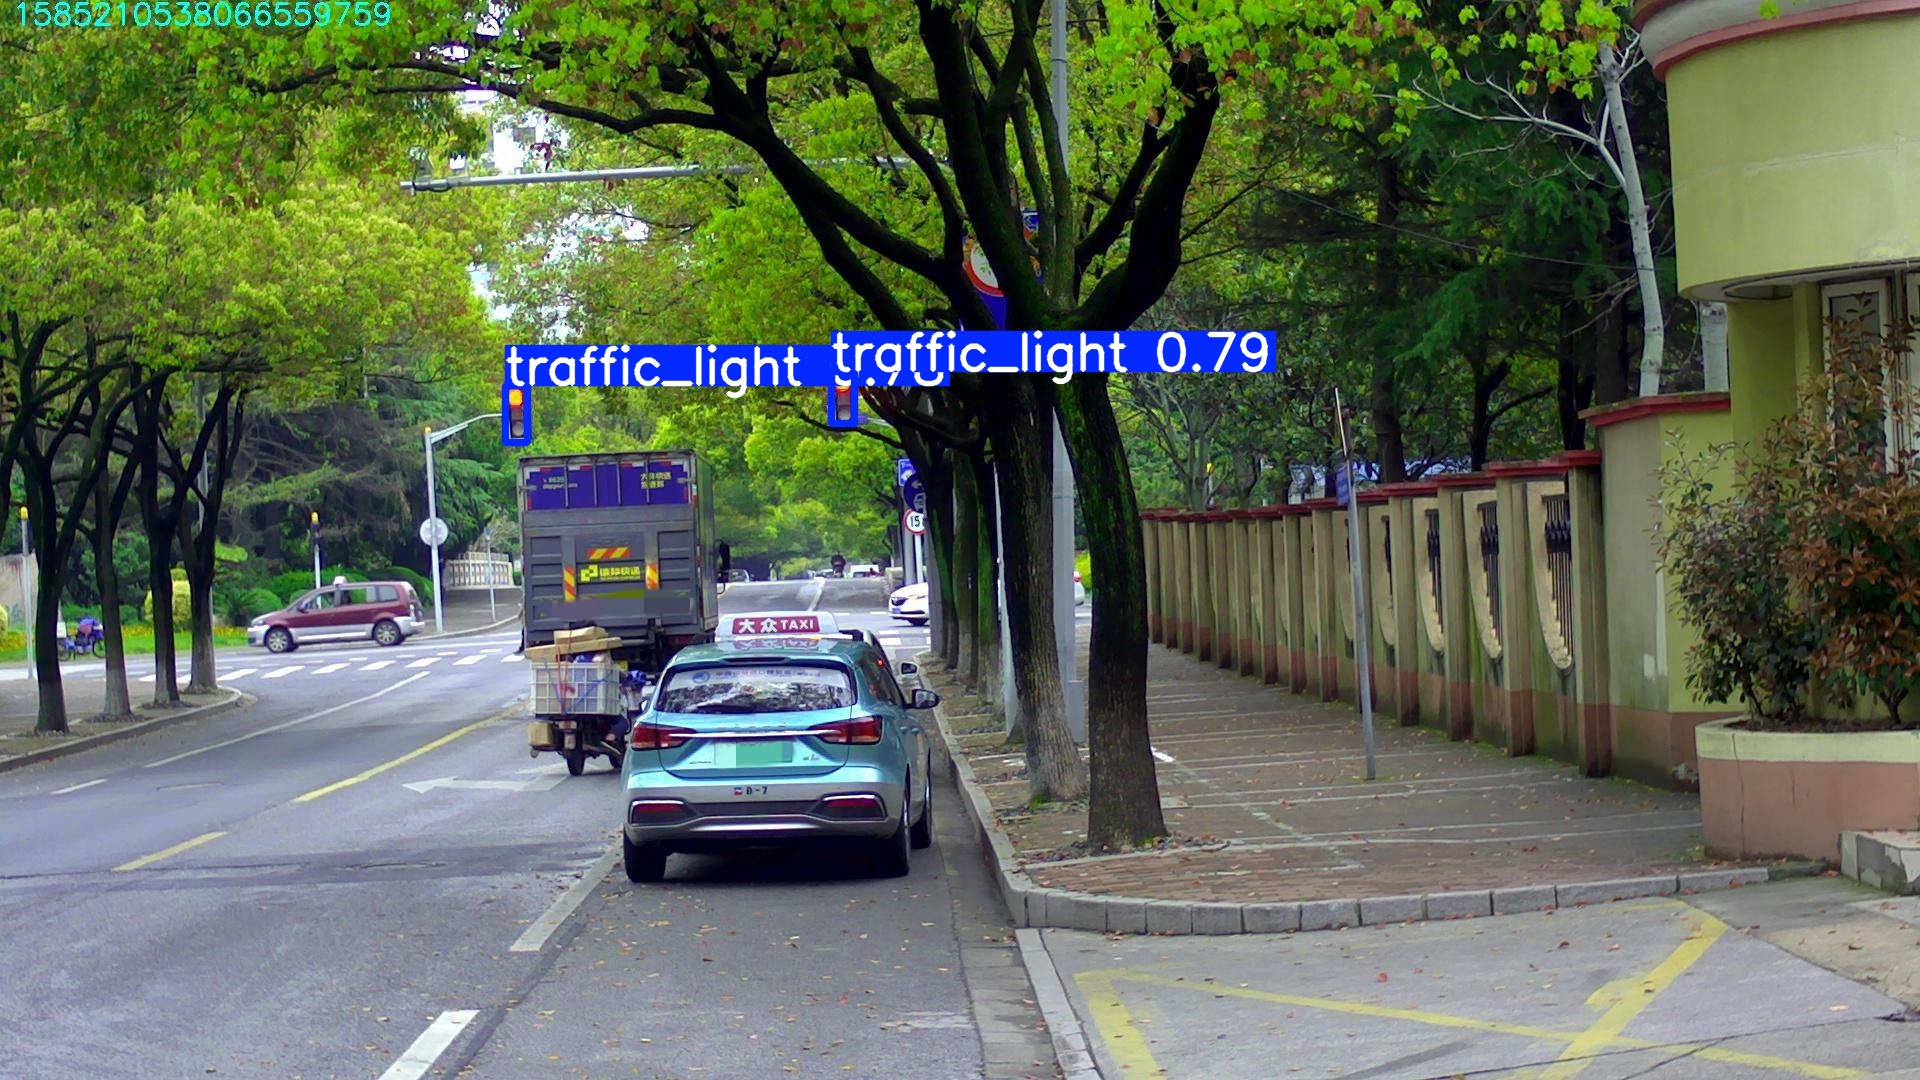

In [68]:
from IPython.display import Image, display

result_image = "/content/runs/detect/predict/2020-03-30 11_48_29.109960876.jpg"

display(Image(filename=result_image))

In [69]:
import torch
import torch.nn as nn
from torchvision import models, transforms

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate ResNet18
color_model = models.resnet18(weights=None)

# 3 classes: green, red, yellow
color_model.fc = nn.Linear(
    color_model.fc.in_features,
    3
)

# Load our trained weights
color_model.load_state_dict(
    torch.load(
        "/content/traffic_color_classifier/best_color_classifier.pth",
        map_location=device
    )
)

color_model = color_model.to(device)
color_model.eval()

# Same class order used by ImageFolder
class_names = ["green", "red", "yellow"]

# Image preprocessing
color_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

print("ResNet18 color classifier loaded!")
print("Classes:", class_names)

ResNet18 color classifier loaded!
Classes: ['green', 'red', 'yellow']


In [70]:
from PIL import Image
import torch

# Test image
image_path = "/content/yolo_traffic_light_dataset/images/val/2020-03-30 11_48_29.109960876.jpg"

# Load original image
image = Image.open(image_path).convert("RGB")

# YOLO detection
results = yolo_model.predict(
    source=image,
    conf=0.25,
    verbose=False
)

result = results[0]

print("Traffic lights detected:", len(result.boxes))

# Process every detected traffic light
for i, box in enumerate(result.boxes):

    # Bounding box coordinates
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

    # Crop traffic light
    crop = image.crop((x1, y1, x2, y2))

    # Prepare crop for ResNet18
    input_tensor = color_transform(crop).unsqueeze(0).to(device)

    # Color prediction
    with torch.no_grad():
        output = color_model(input_tensor)
        probabilities = torch.softmax(output, dim=1)

    predicted_index = torch.argmax(probabilities, dim=1).item()
    predicted_color = class_names[predicted_index]
    confidence = probabilities[0][predicted_index].item()

    print(
        f"Traffic Light {i+1}: "
        f"{predicted_color.upper()} "
        f"({confidence:.2%})"
    )

Traffic lights detected: 2
Traffic Light 1: YELLOW (64.75%)
Traffic Light 2: RED (69.27%)


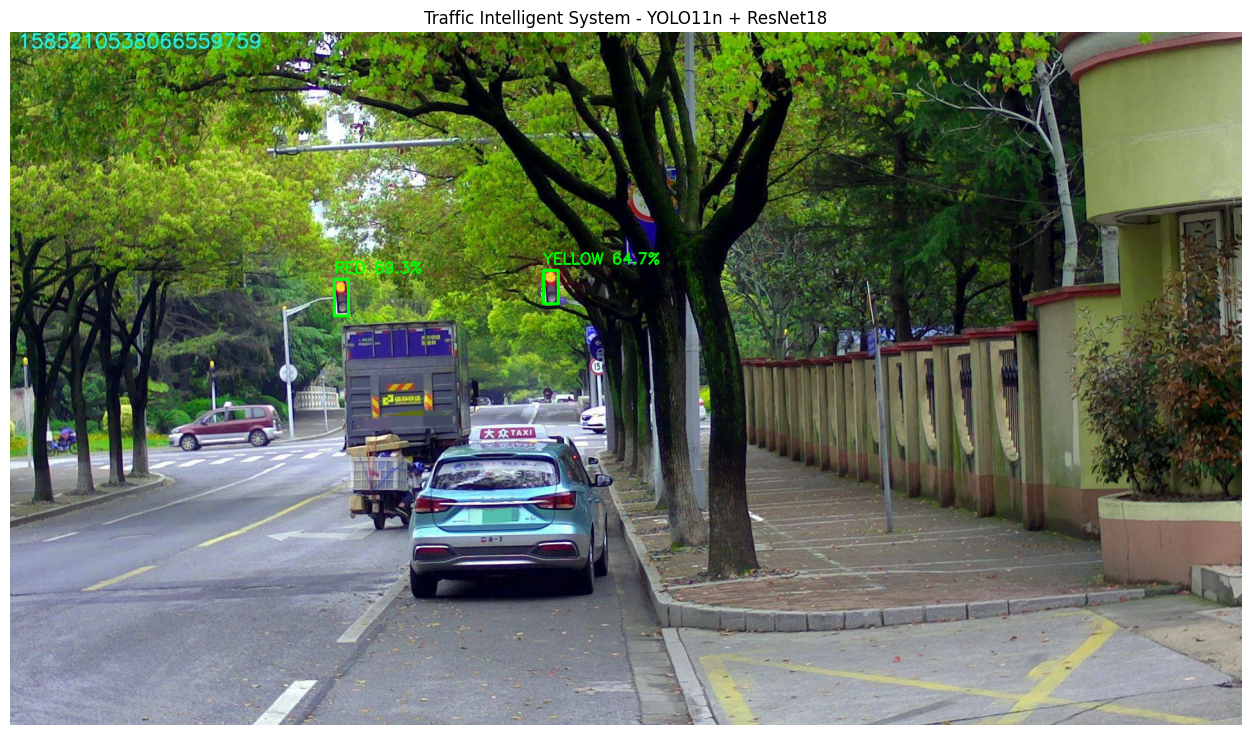

In [71]:
import cv2
import torch
from PIL import Image
from matplotlib import pyplot as plt

# Test image
image_path = "/content/yolo_traffic_light_dataset/images/val/2020-03-30 11_48_29.109960876.jpg"

# Load image
image = Image.open(image_path).convert("RGB")

# YOLO detection
results = yolo_model.predict(
    source=image,
    conf=0.25,
    verbose=False
)

result = results[0]

# Convert PIL image to OpenCV
output_image = cv2.cvtColor(
    __import__("numpy").array(image),
    cv2.COLOR_RGB2BGR
)

for i, box in enumerate(result.boxes):

    # Bounding box
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

    # Crop traffic light
    crop = image.crop((x1, y1, x2, y2))

    # ResNet preprocessing
    input_tensor = color_transform(crop).unsqueeze(0).to(device)

    # Color prediction
    with torch.no_grad():
        output = color_model(input_tensor)
        probabilities = torch.softmax(output, dim=1)

    predicted_index = torch.argmax(probabilities, dim=1).item()
    predicted_color = class_names[predicted_index]
    confidence = probabilities[0][predicted_index].item()

    # Label
    label = f"{predicted_color.upper()} {confidence:.1%}"

    # Draw bounding box
    cv2.rectangle(
        output_image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        3
    )

    # Draw label
    cv2.putText(
        output_image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

# Convert back to RGB
output_image = cv2.cvtColor(
    output_image,
    cv2.COLOR_BGR2RGB
)

# Display
plt.figure(figsize=(16, 9))
plt.imshow(output_image)
plt.axis("off")
plt.title("Traffic Intelligent System - YOLO11n + ResNet18")
plt.show()

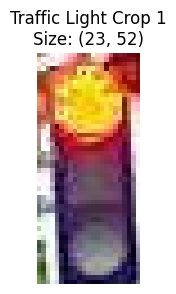

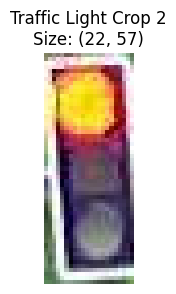

In [72]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "/content/yolo_traffic_light_dataset/images/val/2020-03-30 11_48_29.109960876.jpg"

image = Image.open(image_path).convert("RGB")

results = yolo_model.predict(
    source=image,
    conf=0.25,
    verbose=False
)

result = results[0]

for i, box in enumerate(result.boxes):

    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

    crop = image.crop((x1, y1, x2, y2))

    plt.figure(figsize=(3, 3))
    plt.imshow(crop)
    plt.title(f"Traffic Light Crop {i+1}\nSize: {crop.size}")
    plt.axis("off")
    plt.show()

In [73]:
import os
import xml.etree.ElementTree as ET

image_name = "2020-03-30 11_48_29.109960876.jpg"

xml_path = (
    "/content/s2tld_dataset/s2tld/S2TLD_1080x1920/"
    "Annotations/"
    + image_name.replace(".jpg", ".xml")
)

tree = ET.parse(xml_path)
root = tree.getroot()

print("Ground-truth colors for:", image_name)
print("-" * 40)

for obj in root.findall("object"):
    color = obj.find("name").text
    box = obj.find("bndbox")

    xmin = box.find("xmin").text
    ymin = box.find("ymin").text
    xmax = box.find("xmax").text
    ymax = box.find("ymax").text

    print(
        f"Color: {color.upper()} | "
        f"Box: ({xmin}, {ymin}, {xmax}, {ymax})"
    )

Ground-truth colors for: 2020-03-30 11_48_29.109960876.jpg
----------------------------------------
Color: RED | Box: (505, 386, 529, 440)
Color: RED | Box: (832, 371, 855, 425)


In [75]:
from PIL import Image
import torch

image_path = "/content/s2tld_dataset/s2tld/S2TLD_1080x1920/valid_images/2020-03-30 11_48_29.109960876.jpg"

image = Image.open(image_path).convert("RGB")

# Ground-truth boxes from the XML
ground_truth_boxes = [
    (505, 386, 529, 440),
    (832, 371, 855, 425)
]

for i, box in enumerate(ground_truth_boxes):

    crop = image.crop(box)

    input_tensor = color_transform(crop).unsqueeze(0).to(device)

    with torch.no_grad():
        output = color_model(input_tensor)
        probabilities = torch.softmax(output, dim=1)

    predicted_index = torch.argmax(probabilities, dim=1).item()
    predicted_color = class_names[predicted_index]
    confidence = probabilities[0][predicted_index].item()

    print(
        f"Ground Truth: RED | "
        f"Prediction: {predicted_color.upper()} | "
        f"Confidence: {confidence:.2%} | "
        f"Crop Size: {crop.size}"
    )

Ground Truth: RED | Prediction: RED | Confidence: 63.95% | Crop Size: (24, 54)
Ground Truth: RED | Prediction: YELLOW | Confidence: 60.99% | Crop Size: (23, 54)


In [76]:
import os
import xml.etree.ElementTree as ET
from collections import Counter

base = "/content/s2tld_dataset/s2tld/S2TLD_1080x1920"

train_xml = os.path.join(base, "train_annotations")

color_counts = Counter()

for xml_file in os.listdir(train_xml):

    if not xml_file.endswith(".xml"):
        continue

    xml_path = os.path.join(train_xml, xml_file)

    tree = ET.parse(xml_path)
    root = tree.getroot()

    for obj in root.findall("object"):
        color = obj.find("name").text.lower()

        if color in ["red", "yellow", "green"]:
            color_counts[color] += 1

print("S2TLD training crops available:")
print("-" * 35)

for color in ["red", "yellow", "green"]:
    print(f"{color.upper():<8}: {color_counts[color]}")

print("\nTotal:", sum(color_counts.values()))

S2TLD training crops available:
-----------------------------------
RED     : 1022
YELLOW  : 68
GREEN   : 684

Total: 1774


In [78]:
import os
import shutil
import xml.etree.ElementTree as ET
from PIL import Image

base = "/content/s2tld_dataset/s2tld/S2TLD_1080x1920"
output = "/content/s2tld_color_crops"

# Start fresh
if os.path.exists(output):
    shutil.rmtree(output)

# Create folders
for split in ["train", "val"]:
    for color in ["red", "green", "yellow"]:
        os.makedirs(
            os.path.join(output, split, color),
            exist_ok=True
        )


def create_crops(image_folder, xml_folder, split):

    counts = {"red": 0, "green": 0, "yellow": 0}
    skipped = 0

    for xml_file in os.listdir(xml_folder):

        if not xml_file.endswith(".xml"):
            continue

        xml_path = os.path.join(xml_folder, xml_file)

        image_name = os.path.splitext(xml_file)[0] + ".jpg"
        image_path = os.path.join(image_folder, image_name)

        if not os.path.exists(image_path):
            continue

        image = Image.open(image_path).convert("RGB")

        tree = ET.parse(xml_path)
        root = tree.getroot()

        for obj_index, obj in enumerate(root.findall("object")):

            color = obj.find("name").text.lower()

            if color not in ["red", "green", "yellow"]:
                continue

            box = obj.find("bndbox")

            xmin = int(float(box.find("xmin").text))
            ymin = int(float(box.find("ymin").text))
            xmax = int(float(box.find("xmax").text))
            ymax = int(float(box.find("ymax").text))

            # Check bounding box
            if xmax <= xmin or ymax <= ymin:
                skipped += 1
                continue

            # Keep coordinates inside image
            xmin = max(0, min(xmin, image.width - 1))
            ymin = max(0, min(ymin, image.height - 1))
            xmax = max(0, min(xmax, image.width))
            ymax = max(0, min(ymax, image.height))

            # Check again after clipping
            if xmax <= xmin or ymax <= ymin:
                skipped += 1
                continue

            crop = image.crop((xmin, ymin, xmax, ymax))

            # Final safety check
            if crop.width == 0 or crop.height == 0:
                skipped += 1
                continue

            filename = (
                f"{os.path.splitext(xml_file)[0]}"
                f"_light_{obj_index}.jpg"
            )

            save_path = os.path.join(
                output,
                split,
                color,
                filename
            )

            crop.save(save_path)

            counts[color] += 1

    print(f"\n{split.upper()} crops created:")
    print(f"RED      : {counts['red']}")
    print(f"GREEN    : {counts['green']}")
    print(f"YELLOW   : {counts['yellow']}")
    print(f"Skipped  : {skipped}")


create_crops(
    os.path.join(base, "train_images"),
    os.path.join(base, "train_annotations"),
    "train"
)

create_crops(
    os.path.join(base, "valid_images"),
    os.path.join(base, "valid_annotations"),
    "val"
)

print("\nS2TLD color crop dataset created successfully!")


TRAIN crops created:
RED      : 1021
GREEN    : 684
YELLOW   : 68
Skipped  : 1

VAL crops created:
RED      : 213
GREEN    : 132
YELLOW   : 7
Skipped  : 0

S2TLD color crop dataset created successfully!


In [79]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Paths
train_path = "/content/s2tld_color_crops/train"
val_path = "/content/s2tld_color_crops/val"

# ImageNet normalization
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Validation transformations
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Datasets
train_dataset = datasets.ImageFolder(
    train_path,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_path,
    transform=val_transform
)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

Classes: ['green', 'red', 'yellow']
Training images: 1773
Validation images: 352


In [80]:
from collections import Counter
import torch

# Count training samples for each class
class_counts = Counter(train_dataset.targets)

print("Class counts:")
for class_index, class_name in enumerate(train_dataset.classes):
    print(f"{class_name.upper():<8}: {class_counts[class_index]}")

# Calculate balanced class weights
total = sum(class_counts.values())
num_classes = len(train_dataset.classes)

class_weights = []

for class_index in range(num_classes):
    weight = total / (num_classes * class_counts[class_index])
    class_weights.append(weight)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("\nClass weights:")
for class_name, weight in zip(
    train_dataset.classes,
    class_weights
):
    print(f"{class_name.upper():<8}: {weight.item():.2f}")

Class counts:
GREEN   : 684
RED     : 1021
YELLOW  : 68

Class weights:
GREEN   : 0.86
RED     : 0.58
YELLOW  : 8.69


In [81]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim

# Load pretrained ResNet18
color_model = models.resnet18(weights="DEFAULT")

# Replace final layer for 3 traffic-light colors
color_model.fc = nn.Linear(
    color_model.fc.in_features,
    3
)

# Move model to GPU
color_model = color_model.to(device)

# Weighted loss
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Optimizer
optimizer = optim.Adam(
    color_model.parameters(),
    lr=0.0001
)

print("ResNet18 ready!")
print("Classes:", train_dataset.classes)
print("Device:", device)
print("Weighted loss: enabled")

ResNet18 ready!
Classes: ['green', 'red', 'yellow']
Device: cuda
Weighted loss: enabled


In [82]:
num_epochs = 10

for epoch in range(num_epochs):

    # --------------------
    # Training
    # --------------------
    color_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = color_model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    # --------------------
    # Validation
    # --------------------
    color_model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = color_model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total
    val_loss = val_loss / len(val_loader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Accuracy: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )

Epoch [1/10] Train Loss: 0.1749 Train Accuracy: 93.18% Val Loss: 0.0164 Val Accuracy: 100.00%
Epoch [2/10] Train Loss: 0.0253 Train Accuracy: 99.66% Val Loss: 0.0109 Val Accuracy: 100.00%
Epoch [3/10] Train Loss: 0.0152 Train Accuracy: 99.32% Val Loss: 0.0055 Val Accuracy: 100.00%
Epoch [4/10] Train Loss: 0.0136 Train Accuracy: 99.72% Val Loss: 0.0084 Val Accuracy: 99.72%
Epoch [5/10] Train Loss: 0.0185 Train Accuracy: 99.44% Val Loss: 0.0014 Val Accuracy: 100.00%
Epoch [6/10] Train Loss: 0.0062 Train Accuracy: 99.89% Val Loss: 0.0030 Val Accuracy: 100.00%
Epoch [7/10] Train Loss: 0.0100 Train Accuracy: 99.77% Val Loss: 0.0034 Val Accuracy: 100.00%
Epoch [8/10] Train Loss: 0.0308 Train Accuracy: 98.98% Val Loss: 0.0006 Val Accuracy: 100.00%
Epoch [9/10] Train Loss: 0.0119 Train Accuracy: 99.66% Val Loss: 0.0183 Val Accuracy: 99.43%
Epoch [10/10] Train Loss: 0.0262 Train Accuracy: 99.49% Val Loss: 0.0011 Val Accuracy: 100.00%


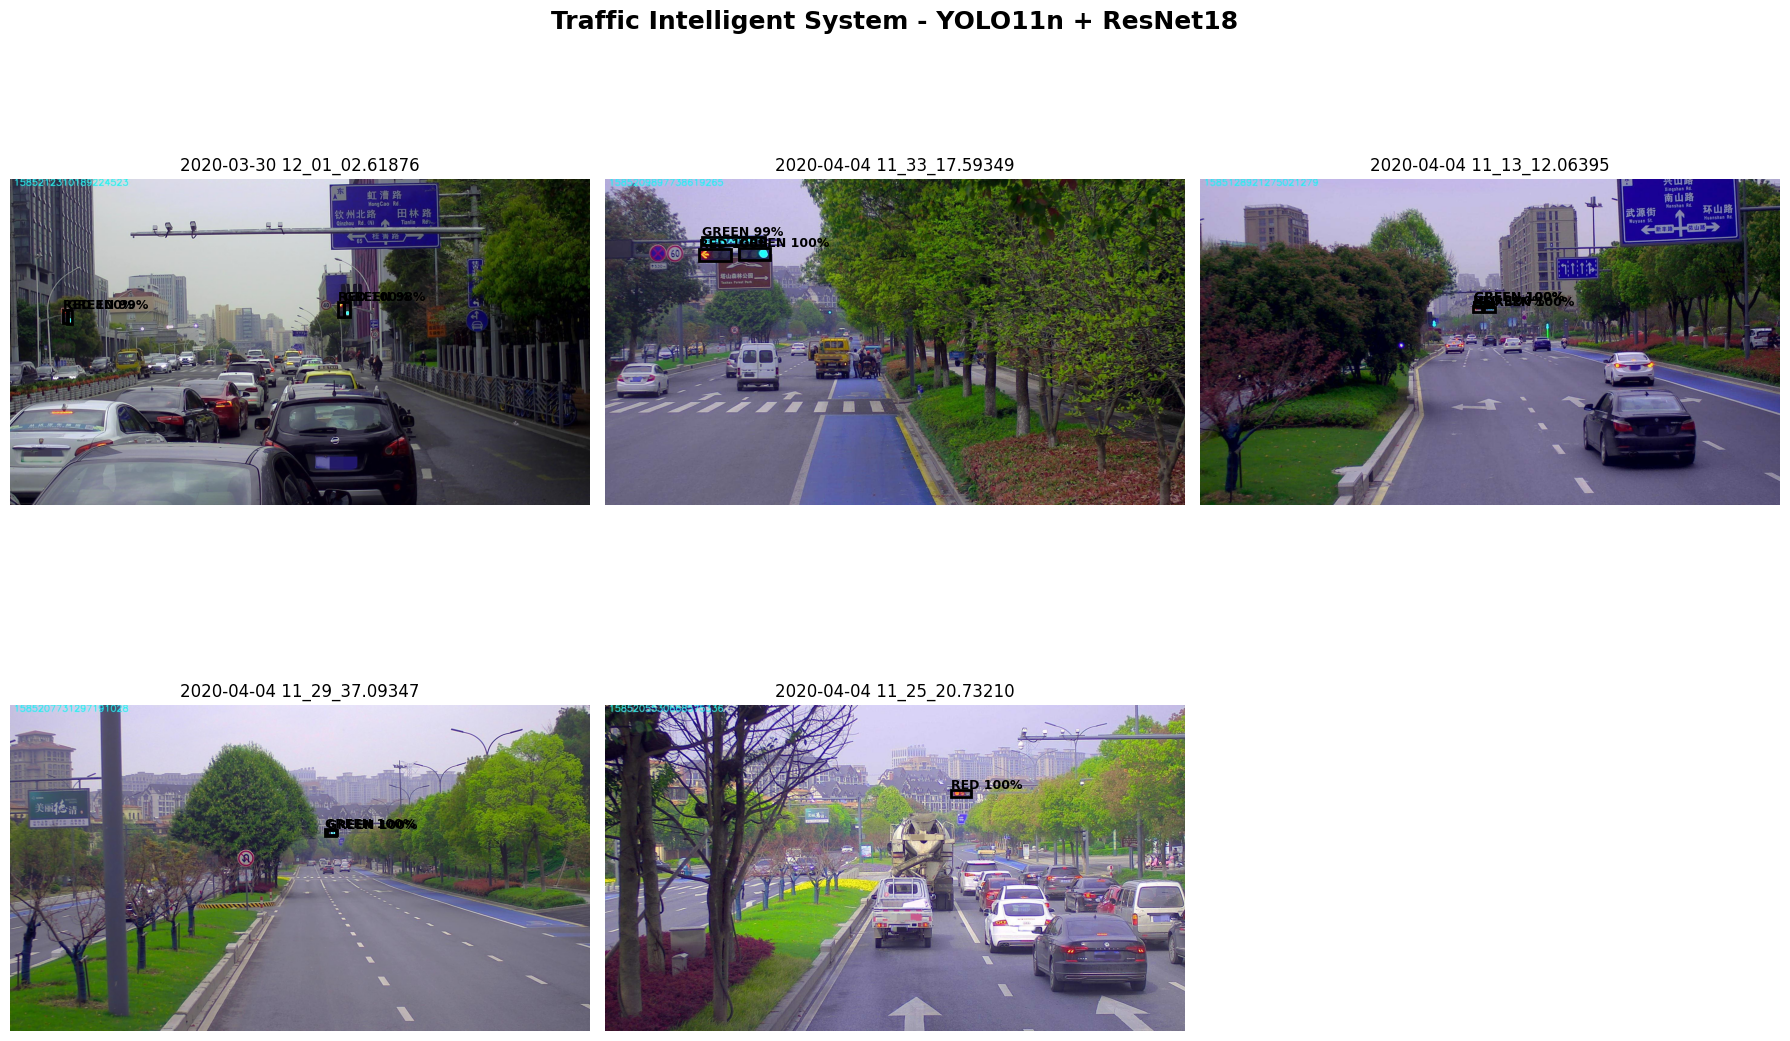

In [108]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import torch

# Validation image folder
val_folder = (
    "/content/s2tld_dataset/s2tld/"
    "S2TLD_1080x1920/valid_images"
)

# Select 5 random images
image_files = [
    f for f in os.listdir(val_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random.seed(42)
selected_images = random.sample(image_files, 5)

plt.figure(figsize=(18, 12))

for idx, image_name in enumerate(selected_images):

    image_path = os.path.join(val_folder, image_name)
    image = Image.open(image_path).convert("RGB")

    # YOLO detection
    results = yolo_model.predict(
        source=image,
        conf=0.25,
        verbose=False
    )

    result = results[0]

    ax = plt.subplot(2, 3, idx + 1)
    ax.imshow(image)

    for box in result.boxes:

        x1, y1, x2, y2 = (
            box.xyxy[0]
            .cpu()
            .numpy()
            .astype(int)
        )

        # Crop detected traffic light
        crop = image.crop((x1, y1, x2, y2))

        # ResNet classification
        input_tensor = val_transform(crop).unsqueeze(0).to(device)

        with torch.no_grad():
            output = color_model(input_tensor)
            probabilities = torch.softmax(output, dim=1)

        predicted_index = torch.argmax(
            probabilities,
            dim=1
        ).item()

        predicted_color = train_dataset.classes[predicted_index]
        confidence = probabilities[0][predicted_index].item()

        # Draw bounding box
        rectangle = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rectangle)

        # Label
        ax.text(
            x1,
            max(y1 - 5, 5),
            f"{predicted_color.upper()} {confidence:.0%}",
            fontsize=9,
            fontweight="bold"
        )

    ax.set_title(image_name[:25])
    ax.axis("off")

plt.suptitle(
    "Traffic Intelligent System - YOLO11n + ResNet18",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [109]:
from ultralytics import YOLO

# Load your best trained YOLO11n model
best_yolo = YOLO(
    "/content/traffic_light_training/"
    "s2tld_yolo11n/weights/best.pt"
)

# Evaluate on validation set
metrics = best_yolo.val(
    data="/content/yolo_traffic_light_dataset/data.yaml",
    split="val",
    imgsz=640
)

print("YOLO11n Evaluation")
print("-------------------")
print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")
print(f"mAP@50    : {metrics.box.map50:.4f}")
print(f"mAP@50-95 : {metrics.box.map:.4f}")

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3233.4±373.5 MB/s, size: 264.6 KB)
val: Scanning /content/yolo_traffic_light_dataset/labels/val.cache... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 41.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.5it/s 5.1s
                   all        200        402       0.93      0.888      0.932       0.49
Speed: 2.0ms preprocess, 3.9ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/val-2
YOLO11n Evaluation
-------------------
Precision : 0.9295
Recall    : 0.8881
mAP@50    : 0.9324
mAP@50-95 : 0.4903


In [95]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Evaluate ResNet18
color_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = color_model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

# Classification report
print("ResNet18 Color Classification Results")
print("---------------------------------------")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=train_dataset.classes,
        digits=4
    )
)

ResNet18 Color Classification Results
---------------------------------------
              precision    recall  f1-score   support

       green     1.0000    1.0000    1.0000       132
         red     1.0000    1.0000    1.0000       213
      yellow     1.0000    1.0000    1.0000         7

    accuracy                         1.0000       352
   macro avg     1.0000    1.0000    1.0000       352
weighted avg     1.0000    1.0000    1.0000       352



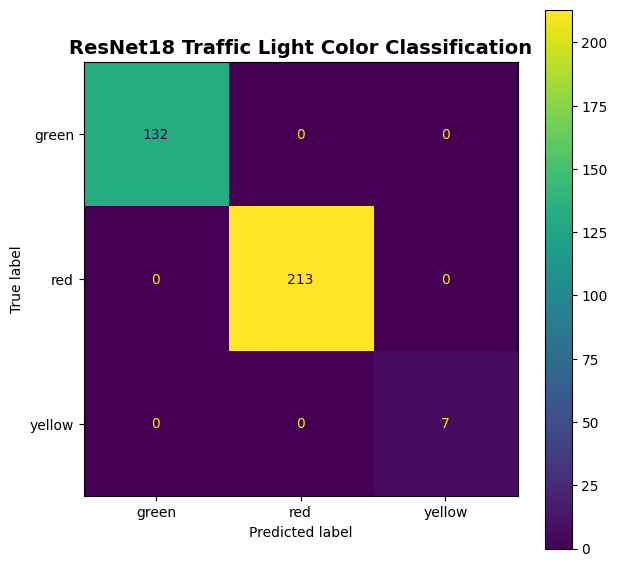

In [96]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title(
    "ResNet18 Traffic Light Color Classification",
    fontsize=14,
    fontweight="bold"
)

plt.show()